# Outlier Detection and Treatment

Outliers are data points that significantly differ from the rest of the observations in a dataset.

They may occur due to data entry errors, measurement errors, or genuine extreme values. If not handled properly, outliers can negatively impact statistical analysis and Machine Learning models.

The objective of outlier detection is to identify these unusual observations and decide whether to remove, transform, or retain them based on the problem domain.

# Detecting Outliers

There are several statistical and visualization techniques to identify outliers.

The most commonly used methods include:

- Z-Score Method
- Interquartile Range (IQR)
- Box Plot
- Scatter Plot
- Standard Deviation Method

## Method 1 — Z-Score

The Z-Score measures how many standard deviations a data point is away from the mean.

Generally:

- Z > 3 → Outlier
- Z < -3 → Outlier

In [ ]:
## Import Libraries
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 

In [2]:
## Load Dataset

df = sns.load_dataset("titanic")

In [4]:
from scipy.stats import zscore 

df["Age_Zscore"] = zscore(df["age"])

outliers = df[df["Age_Zscore"].abs() > 3]

outliers.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone,Age_Zscore


- A large absolute Z-Score indicates that the observation is unusually far from the average value and may be considered an outlier.

## Method 2 — Interquartile Range (IQR)

The IQR method identifies outliers using the first quartile (Q1) and third quartile (Q3).

Formula:

- IQR = Q3 − Q1
- Lower Bound = Q1 − 1.5 × IQR
- Upper Bound = Q3 + 1.5 × IQR

Values outside these boundaries are considered outliers.

In [6]:
Q1 = df["fare"].quantile(0.25)
Q3 = df["fare"].quantile(0.75)

IQR = Q3 - Q1 

lower_bound = Q1 - (1.5 * IQR)
upper_bound = Q3 + (1.5 * IQR)

outliers = df[(df["fare"] < lower_bound) | (df["fare"] > upper_bound)]

outliers.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone,Age_Zscore
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False,NaN
27,0,1,male,19.0,3,2,263.0000,S,First,man,True,C,Southampton,no,False,NaN
31,1,1,female,NaN,1,0,146.5208,C,First,woman,False,B,Cherbourg,yes,False,NaN
34,0,1,male,28.0,1,0,82.1708,C,First,man,True,NaN,Cherbourg,no,False,NaN
52,1,1,female,49.0,1,0,76.7292,C,First,woman,False,D,Cherbourg,yes,False,NaN


- The IQR method is widely used because it is robust to skewed data and does not assume a normal distribution.

## Method 3 — Box Plot

A Box Plot provides a visual representation of data distribution and highlights potential outliers.

Points outside the whiskers are considered possible outliers.

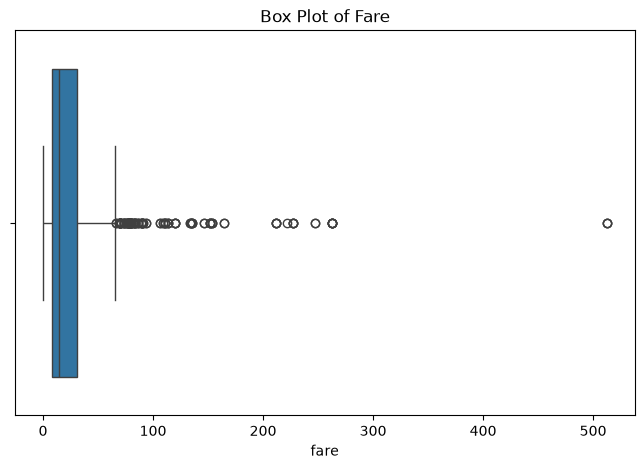

In [7]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df["fare"])
plt.title("Box Plot of Fare")
plt.show()

- The box represents the interquartile range (IQR), while the whiskers extend to the expected data range. Individual points outside the whiskers are potential outliers.

## Method 4 — Scatter Plot

Scatter plots help visualize unusual observations by comparing two numerical features.

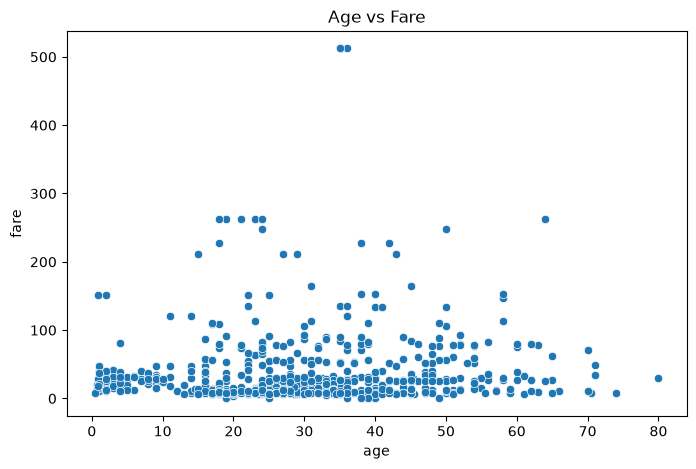

In [8]:
plt.figure(figsize=(8,5))

sns.scatterplot(data=df, x="age", y="fare")

plt.title("Age vs Fare")

plt.show()

- Observations that appear far away from the main cluster may represent outliers.

## Method 5 — Standard Deviation Method

This approach identifies observations lying beyond three standard deviations from the mean.

It is mainly suitable for approximately normally distributed data.

In [9]:
mean = df["fare"].mean()
std = df["fare"].std()

lower = mean - (3 * std)
upper = mean + (3 * std)

outliers = df[(df["fare"] < lower) | (df["fare"] > upper)]

outliers.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone,Age_Zscore
27,0,1,male,19.0,3,2,263.0000,S,First,man,True,C,Southampton,no,False,NaN
88,1,1,female,23.0,3,2,263.0000,S,First,woman,False,C,Southampton,yes,False,NaN
118,0,1,male,24.0,0,1,247.5208,C,First,man,True,B,Cherbourg,no,False,NaN
258,1,1,female,35.0,0,0,512.3292,C,First,woman,False,NaN,Cherbourg,yes,True,NaN
299,1,1,female,50.0,0,1,247.5208,C,First,woman,False,B,Cherbourg,yes,False,NaN


# Outlier Treatment

Once outliers have been identified, appropriate techniques can be applied depending on the dataset and business problem.

Common approaches include:

- Removing outliers
- Winsorization
- Capping
- Data Transformation
- Domain-specific handling

## Method 1 — Remove Outliers

Outliers can be removed if they are caused by data entry or measurement errors.

In [10]:
clean_df = df[(df["fare"] >= lower_bound) & (df["fare"] <= upper_bound)]

clean_df.shape

(775, 16)

- Removing outliers should only be performed when they do not represent meaningful real-world observations.

## Method 2 — Winsorization

Winsorization replaces extreme values with the nearest acceptable boundary instead of deleting them.

In [13]:
%pip install feature-engine

   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   -------------------------------

In [15]:
from feature_engine.outliers import Winsorizer 

winsorizer = Winsorizer( capping_method = "iqr", tail = "both", fold = 1.5)

df["Fare_Winsorized"] = winsorizer.fit_transform(df[["fare"]])

- Winsorization preserves all observations while reducing the influence of extreme values.

## Method 3 — Capping

Capping limits values that exceed predefined lower and upper boundaries.

In [17]:
df["Fare_Capped"] = df["fare"].clip(lower=lower_bound,upper=upper_bound)

- Unlike removal, capping keeps all observations while limiting the effect of extreme values.

## Method 4 — Log Transformation

Log Transformation reduces the effect of highly skewed numerical features.

In [18]:
import numpy as np 

df ["Fare_Log"] = np.log1p(df["fare"])

df[["fare", "Fare_Log"]].head()

,fare,Fare_Log
0,7.2500,2.110213
1,71.2833,4.280593
2,7.9250,2.188856
3,53.1000,3.990834
4,8.0500,2.202765


- Log Transformation compresses large values more than smaller values, helping reduce skewness and the impact of outliers.

## Method 5 — Domain-Specific Handling

Not every outlier should be removed.

Some extreme values represent genuine observations.

For example:

- Luxury houses with exceptionally high prices
- VIP airline passengers with expensive tickets
- High-income customers

Such observations may contain valuable information and should be retained if they are valid.